# 数据增强 

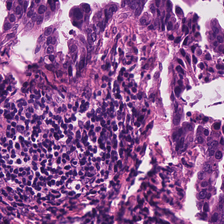

In [1]:
from PIL import Image
# 图像路径
image_path = "luad.png"

img = Image.open(image_path)
img

In [2]:
img.size

(224, 224)

## 1.图像缩放

In [3]:
from torchvision import transforms
from PIL import Image

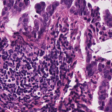

In [4]:
# 图像路径
image_path = "luad.png"
# transforms.Resize(
#     size,
#     interpolation=<InterpolationMode.BILINEAR: 'bilinear'>,
#     max_size=None,
#     antialias=None,
# )
# 创建一个Resize对象进行图像的缩放
resize = transforms.Resize((112,112))

# 读取原图
img = Image.open(image_path)
resized_img = resize(img)
resized_img

In [5]:
resized_img.size

(112, 112)

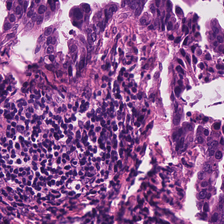

In [7]:
img

## 2.随机裁剪

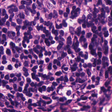

In [6]:
# 图像路径
image_path = "luad.png"
# transforms.RandomCrop(
#     size,
#     padding=None,
#     pad_if_needed=False,
#     fill=0,
#     padding_mode='constant',
# )
# 创建RandomCrop转换对象
crop = transforms.RandomCrop(size=(112,112))
# 读取原图
img = Image.open(image_path)
croped_img = crop(img)
croped_img

## 3.图像翻转

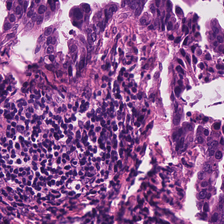

In [13]:
img

In [20]:
# 图像路径
image_path = "luad.png"

# 创建一个水平翻转转换对象
#     p (float): probability of the image being flipped. Default value is 0.5

hf = transforms.RandomHorizontalFlip(p=1)
vf = transforms.RandomVerticalFlip(p=0.5)

img = Image.open(image_path)

hfed_img = hf(img)

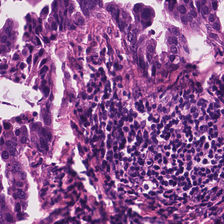

In [21]:
hfed_img

In [22]:
import numpy as np
np.array(img) # 0-255

array([[[219, 181, 207],
        [185, 145, 196],
        [220, 192, 216],
        ...,
        [239, 232, 238],
        [224, 187, 212],
        [172, 110, 165]],

       [[241, 221, 227],
        [226, 194, 214],
        [209, 174, 207],
        ...,
        [240, 236, 238],
        [215, 181, 205],
        [150,  89, 153]],

       [[243, 233, 233],
        [238, 225, 232],
        [238, 210, 218],
        ...,
        [235, 230, 236],
        [223, 194, 206],
        [115,  65, 138]],

       ...,

       [[106,  50, 124],
        [136,  70, 144],
        [145,  63, 130],
        ...,
        [ 91,  44, 118],
        [ 93,  42, 115],
        [ 83,  40, 117]],

       [[111,  46, 116],
        [102,  39,  97],
        [ 68,  29,  90],
        ...,
        [122,  55, 129],
        [111,  46, 112],
        [ 90,  38, 114]],

       [[ 84,  35, 104],
        [ 92,  35,  88],
        [ 69,  29,  88],
        ...,
        [122,  53, 124],
        [ 86,  40, 109],
        [ 94,  43, 118]]

In [27]:
np.array(img).shape

(224, 224, 3)

## 4.ToTensor操作

In [24]:
# 图像路径
image_path = "luad.png"
# 创建一个ToTensor转换对象
to_tensor = transforms.ToTensor()
img = Image.open(image_path)
tensored_img = to_tensor(img)
tensored_img # 1.[0,1] 2. H,W,C -> C,H,W

tensor([[[0.8588, 0.7255, 0.8627,  ..., 0.9373, 0.8784, 0.6745],
         [0.9451, 0.8863, 0.8196,  ..., 0.9412, 0.8431, 0.5882],
         [0.9529, 0.9333, 0.9333,  ..., 0.9216, 0.8745, 0.4510],
         ...,
         [0.4157, 0.5333, 0.5686,  ..., 0.3569, 0.3647, 0.3255],
         [0.4353, 0.4000, 0.2667,  ..., 0.4784, 0.4353, 0.3529],
         [0.3294, 0.3608, 0.2706,  ..., 0.4784, 0.3373, 0.3686]],

        [[0.7098, 0.5686, 0.7529,  ..., 0.9098, 0.7333, 0.4314],
         [0.8667, 0.7608, 0.6824,  ..., 0.9255, 0.7098, 0.3490],
         [0.9137, 0.8824, 0.8235,  ..., 0.9020, 0.7608, 0.2549],
         ...,
         [0.1961, 0.2745, 0.2471,  ..., 0.1725, 0.1647, 0.1569],
         [0.1804, 0.1529, 0.1137,  ..., 0.2157, 0.1804, 0.1490],
         [0.1373, 0.1373, 0.1137,  ..., 0.2078, 0.1569, 0.1686]],

        [[0.8118, 0.7686, 0.8471,  ..., 0.9333, 0.8314, 0.6471],
         [0.8902, 0.8392, 0.8118,  ..., 0.9333, 0.8039, 0.6000],
         [0.9137, 0.9098, 0.8549,  ..., 0.9255, 0.8078, 0.

In [25]:
tensored_img.shape

torch.Size([3, 224, 224])

## 5.操作组合起来 Compose用法

In [28]:
# 创建一个组合的转换操作
# [1,2,3,4,]
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop(112),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    # mean, std
#     transforms.Normalize(mean=[0.5,0.5,0.5],std=[0.5,0.5,0.5])
    
])
img = Image.open(image_path)
changed_img = transform(img)
changed_img

tensor([[[0.3608, 0.3725, 0.3333,  ..., 0.2824, 0.4275, 0.6941],
         [0.4157, 0.3569, 0.3059,  ..., 0.5490, 0.7725, 0.9255],
         [0.4314, 0.3176, 0.2902,  ..., 0.7569, 0.9333, 0.9843],
         ...,
         [0.2549, 0.3529, 0.6392,  ..., 0.7020, 0.8667, 0.9137],
         [0.2588, 0.2745, 0.5490,  ..., 0.7922, 0.8510, 0.7961],
         [0.3137, 0.2510, 0.3804,  ..., 0.7765, 0.6863, 0.5725]],

        [[0.1490, 0.1490, 0.1373,  ..., 0.2039, 0.3608, 0.5961],
         [0.1569, 0.1451, 0.1294,  ..., 0.3686, 0.6431, 0.8353],
         [0.1725, 0.1490, 0.1333,  ..., 0.4824, 0.7725, 0.8902],
         ...,
         [0.1294, 0.2039, 0.3882,  ..., 0.3569, 0.4784, 0.5098],
         [0.1294, 0.1569, 0.3804,  ..., 0.4000, 0.4627, 0.4353],
         [0.1373, 0.1216, 0.2902,  ..., 0.3882, 0.3686, 0.2980]],

        [[0.4000, 0.3765, 0.3804,  ..., 0.4667, 0.6000, 0.7490],
         [0.3882, 0.3686, 0.3608,  ..., 0.6196, 0.7725, 0.8588],
         [0.3961, 0.3843, 0.3804,  ..., 0.7176, 0.8510, 0.

In [31]:
img_array = changed_img.numpy()
img_array.shape # C,H,W

(3, 112, 112)

In [32]:
# matplotlib 需要H,W,C
img_array = img_array.transpose((1,2,0))
img_array.shape

(112, 112, 3)

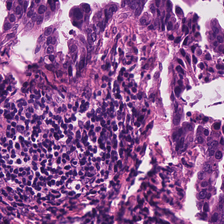

In [35]:
img

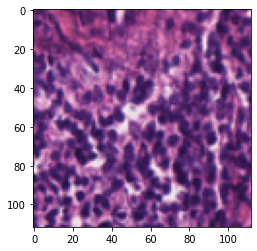

In [33]:
import matplotlib.pyplot as plt
# 显示图像
plt.imshow(img_array)


In [36]:
import torch
import torch.nn as nn

# 搭建一个VGG116

In [49]:
# 要用这个VGG做分类
# num_classes

# nn.Conv2d(
#     in_channels: int,
#     out_channels: int,
#     kernel_size: Union[int, Tuple[int, int]],
#     stride: Union[int, Tuple[int, int]] = 1,
#     padding: Union[str, int, Tuple[int, int]] = 0,
#     dilation: Union[int, Tuple[int, int]] = 1,
#     groups: int = 1,
#     bias: bool = True,
#     padding_mode: str = 'zeros',
#     device=None,
#     dtype=None,
# ) -> None

class VGG16(nn.Module):
    def __init__(self,num_classes=1000):
        super(VGG16,self).__init__()
        
        # 第一个卷积块
        self.conv1_1 = nn.Conv2d(in_channels=3,out_channels=64,kernel_size=3,padding=1)
        self.relu1_1 = nn.ReLU()
#         self.conv1_2 = nn.Conv2d(in_channels=64,out_channels=64,kernel_size=3,padding=1),
        self.conv1_2 = nn.Conv2d(64,64,3,padding=1)
        self.relu1_2 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2,stride=2)
        
        # 第二个卷积块
        self.conv2_1 = nn.Conv2d(64,128,kernel_size=3,padding=1)
        self.relu2_1 = nn.ReLU()
        self.conv2_2 = nn.Conv2d(128,128,kernel_size=3,padding=1)
        self.relu2_2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2,stride=2)
        
        # 第三个卷积块
        self.conv3_1 = nn.Conv2d(128,256,kernel_size=3,padding=1)
        self.relu3_1 = nn.ReLU()
        self.conv3_2 = nn.Conv2d(256,256,kernel_size=3,padding=1)
        self.relu3_2 = nn.ReLU()
        self.conv3_3 = nn.Conv2d(256,256,kernel_size=3,padding=1)
        self.relu3_3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2,stride=2)
        
        # 第四个卷积块
        self.conv4_1 = nn.Conv2d(256,512,kernel_size=3,padding=1)
        self.relu4_1 = nn.ReLU()
        self.conv4_2 = nn.Conv2d(512,512,kernel_size=3,padding=1)
        self.relu4_2 = nn.ReLU()
        self.conv4_3 = nn.Conv2d(512,512,kernel_size=3,padding=1)
        self.relu4_3 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(kernel_size=2,stride=2)
        
        # 第五个卷积块
        self.conv5_1 = nn.Conv2d(512,512,kernel_size=3,padding=1)
        self.relu5_1 = nn.ReLU()
        self.conv5_2 = nn.Conv2d(512,512,kernel_size=3,padding=1)
        self.relu5_2 = nn.ReLU()
        self.conv5_3 = nn.Conv2d(512,512,kernel_size=3,padding=1)
        self.relu5_3 = nn.ReLU()
        self.pool5 = nn.MaxPool2d(kernel_size=2,stride=2)
        
        # 全连接层
        self.fc1 = nn.Linear(7*7*512,4096)
        self.relu_fc1 = nn.ReLU()
        self.fc2 = nn.Linear(4096,4096)
        self.relu_fc2 = nn.ReLU()
        self.fc = nn.Linear(4096,num_classes)
        
    def forward(self,x):
        # 第一个卷积块
        x = self.conv1_1(x)
        x = self.relu1_1(x)
        x = self.conv1_2(x)
        x = self.relu1_2(x)
        x = self.pool1(x)
        
        # 第二个卷积块
        x = self.conv2_1(x)
        x = self.relu2_1(x)
        x = self.conv2_2(x)
        x = self.relu2_2(x)
        x = self.pool2(x)
        
        # 第三个卷积块
        x = self.conv3_1(x)
        x = self.relu3_1(x)
        x = self.conv3_2(x)
        x = self.relu3_2(x)
        x = self.conv3_3(x)
        x = self.relu3_3(x)
        x = self.pool3(x)
        
        # 第四个卷积块
        x = self.conv4_1(x)
        x = self.relu4_1(x)
        x = self.conv4_2(x)
        x = self.relu4_2(x)
        x = self.conv4_3(x)
        x = self.relu4_3(x)
        x = self.pool4(x)
        
        # 第五个卷积块
        x = self.conv5_1(x)
        x = self.relu5_1(x)
        x = self.conv5_2(x)
        x = self.relu5_2(x)
        x = self.conv5_3(x)
        x = self.relu5_3(x)
        x = self.pool5(x)
        
        # b,7,7,512
        # b,h,w,c
        # b,7*7*512
        # 得先展平,再去调用全连接层
        x = x.view(x.size(0),-1)
        
        # 调用全连接层
        x = self.fc1(x)
        x = self.relu_fc1(x)
        x = self.fc2(x)
        x = self.relu_fc2(x)
        x = self.fc(x)
        
        return x

In [50]:
net = VGG16(num_classes=5)
net

VGG16(
  (conv1_1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1_1): ReLU()
  (conv1_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1_2): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2_1): ReLU()
  (conv2_2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2_2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3_1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3_1): ReLU()
  (conv3_2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3_2): ReLU()
  (conv3_3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3_3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4_1): Conv2d(256, 512, kern

In [52]:
# 测试数据测试一下我们的网络是否能前向传播
input_tensor = torch.randn(2,3,224,224)
output = net(input_tensor)

In [53]:
# 2表示我们是2个样本的预测结果
# 5表示的就是我们5个类别的预测概率取值
output.shape

torch.Size([2, 5])

In [54]:
# 小猫、小狗、小猪、小狐狸、小马
output

tensor([[-0.0064,  0.0170, -0.0007,  0.0087, -0.0028],
        [-0.0064,  0.0170, -0.0007,  0.0087, -0.0028]],
       grad_fn=<AddmmBackward0>)

In [ ]:
# [-0.0064,  0.0170, -0.0007,  0.0087, -0.0028]
# 小狗

In [ ]:
# [-0.0064,  0.0170, -0.0007,  0.0087, -0.0028]
# 小狗

## 第二种实现VGG的方式

In [56]:
class VGG16(nn.Module):
    def __init__(self,num_classes=1000):
        super(self,VGG16).__init__()
        
        self.features = self._make_layer()
        
        # 全连接层
        self.fc = nn.Sequential(
            nn.Linear(7*7*512,4096),
            nn.ReLU(),
            nn.Linear(4096,4096),
            nn.ReLU(),
            nn.Linear(4096,num_classes)
        )
        
        
    def forward(self,x):
        x = self.features(x)
        # b,7,7,512
        # b,h,w,c
        # b,7*7*512
        # 得先展平,再去调用全连接层
        x = x.view(x.size(0),-1)
        x = self.fc(x)
        return x
        
    def _make_layer(self):
        layers = []
        cfg = [64,64,'M',128,128,'M',256,256,256,'M',512,512,512,'M',512,512,512,'M']
        in_channels = 3
        
        for v in cfg:
            if v == 'M':
                layers += [nn.MaxPool2d(kernel_size=2,stride=2)]
            else:
                layers += [nn.Conv2d(in_channels,v,kernel_size=3,padding=1),nn.ReLU()]
                in_channels = v
        
        return nn.Sequential(*layers)
                
        

In [57]:
# 测试数据测试一下我们的网络是否能前向传播
input_tensor = torch.randn(2,3,224,224)
output = net(input_tensor)

In [58]:
output.shape

torch.Size([2, 5])

# ResNet残差网络

## 残差块

In [71]:
class ResidualBlock(nn.Module):
    def __init__(self,in_channels,out_channels,stride=1):
        super(ResidualBlock,self).__init__()
        self.conv1 = nn.Conv2d(in_channels,out_channels,kernel_size=3,stride=stride,padding=1,bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels,out_channels,kernel_size=3,stride=1,padding=1,bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 如果输入通道数和输出通道数不同或者步长不为1，需要使用1x1卷积来调整通道数
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels,out_channels,kernel_size=1,stride=stride,bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Sequential()
        
    def forward(self,x):
        identity = x
        
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        
        identity = self.shortcut(identity)
        
        print("x = ",x.shape)
        print("identity = ",identity.shape)
        
        out = x + identity
        
        return self.relu(out) 
        
        
        

In [72]:
## 测试
batch_size = 2
h = 224
w = 224
in_channels = 3
# b,c,h,w
x = torch.randn(batch_size,in_channels,h,w)

out_channel = 10
residualBlock = ResidualBlock(in_channels,out_channel)
output = residualBlock(x)

x =  torch.Size([2, 10, 224, 224])
identity =  torch.Size([2, 10, 224, 224])


In [73]:
output.shape

torch.Size([2, 10, 224, 224])

## Resnet34

In [74]:
import torchvision

In [75]:
vgg16 = torchvision.models.vgg16()

In [76]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [77]:
# torchvision.models.resnet34(
#     pretrained: bool = False,
#     progress: bool = True,
#     **kwargs: Any,
# ) -> torchvision.models.resnet.ResNet
resnet34 = torchvision.models.resnet34(pretrained=True)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\86159/.cache\torch\hub\checkpoints\resnet34-b627a593.pth


  0%|          | 0.00/83.3M [00:00<?, ?B/s]

In [78]:
resnet34

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [79]:
## 测试
batch_size = 2
h = 224
w = 224
in_channels = 3
# b,c,h,w
x = torch.randn(batch_size,in_channels,h,w)

out_channel = 10

outputs = resnet34(x)
outputs

tensor([[-0.1173,  0.2482,  1.0182,  ..., -0.4503,  1.1809,  0.1805],
        [-1.3161, -1.2172, -2.0669,  ..., -0.5727,  0.8871,  2.2786]],
       grad_fn=<AddmmBackward0>)

In [80]:
outputs.shape

torch.Size([2, 1000])